# Dimensionality Reduction & Unsupervised Clustering

**Dataset:** Synthetic student performance data (100 records).

This notebook performs standardization, PCA, explained-variance analysis, K-Means clustering, Elbow Method, Silhouette Score, DBSCAN, Hierarchical clustering, and 2D PCA cluster visualizations.

**Note:** The dataset is synthetic; results demonstrate a reproducible workflow and are not evidence about real students.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("student_performance_synthetic.csv")
df.head()

Saving student_performance_synthetic.csv to student_performance_synthetic.csv


,Student_ID,Study_Time_Hours,Attendance_Percent,Previous_Marks,Final_Marks
0,S001,4,91,67,55
1,S002,5,95,70,51
2,S003,3,91,55,50
3,S004,5,94,83,71
4,S005,5,86,84,66


In [3]:
print("Number of records:", len(df))
print("Columns:", df.columns.tolist())
display(df.describe())

Number of records: 100
Columns: ['Student_ID', 'Study_Time_Hours', 'Attendance_Percent', 'Previous_Marks', 'Final_Marks']


,Study_Time_Hours,Attendance_Percent,Previous_Marks,Final_Marks
count,100.000000,100.000000,100.000000,100.000000
mean,3.690000,85.910000,70.980000,54.840000
std,1.624901,8.343745,8.965681,9.289638
min,1.000000,61.000000,50.000000,35.000000
25%,2.000000,79.750000,64.750000,48.000000
50%,4.000000,85.000000,70.500000,54.000000
75%,5.000000,93.000000,77.250000,62.250000
max,6.000000,100.000000,93.000000,74.000000


## 1. Standardization

Student_ID is excluded because it is an identifier. Study time, attendance, previous marks, and final marks are standardized before PCA and clustering.

In [4]:
from sklearn.preprocessing import StandardScaler

features = ["Study_Time_Hours", "Attendance_Percent", "Previous_Marks", "Final_Marks"]
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

display(pd.DataFrame(X_scaled, columns=features).head())
print("Standardized feature means:", np.round(X_scaled.mean(axis=0), 3))

,Study_Time_Hours,Attendance_Percent,Previous_Marks,Final_Marks
0,0.191742,0.613111,-0.446151,0.017310
1,0.810264,1.094927,-0.109856,-0.415446
2,-0.426781,0.613111,-1.791331,-0.523635
3,0.810264,0.974473,1.347422,1.748336
4,0.810264,0.010841,1.459520,1.207391


Standardized feature means: [ 0.  0. -0. -0.]


## 2. Principal Component Analysis (PCA)

PCA transforms standardized features into principal components. The explained variance ratio shows how much variation each component captures.

In [5]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

variance_table = pd.DataFrame({
    "Component": range(1, len(explained)+1),
    "Explained Variance": explained,
    "Cumulative Variance": cumulative
})
display(variance_table.round(4))

,Component,Explained Variance,Cumulative Variance
0,1,0.6180,0.6180
1,2,0.2316,0.8496
2,3,0.1017,0.9512
3,4,0.0488,1.0000


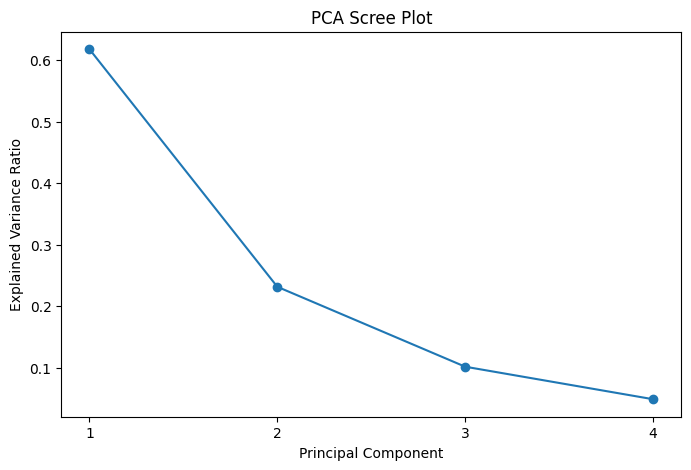

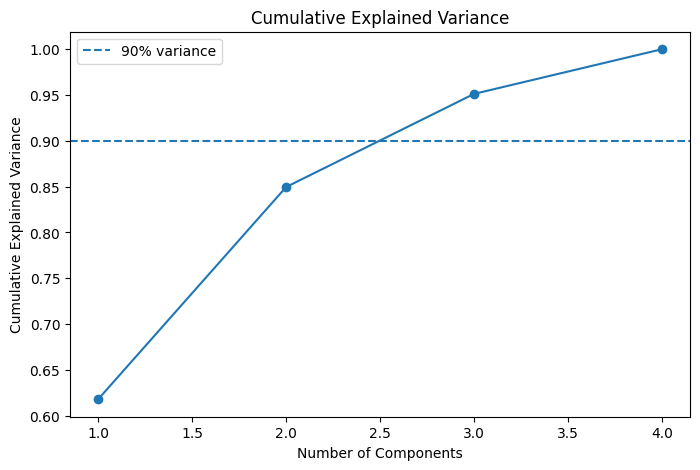

Components needed for at least 90% variance: 3


In [6]:
components = range(1, len(explained)+1)

plt.figure(figsize=(8,5))
plt.plot(components, explained, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.xticks(list(components))
plt.show()

plt.figure(figsize=(8,5))
plt.plot(components, cumulative, marker="o")
plt.axhline(0.90, linestyle="--", label="90% variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.show()

n90 = np.argmax(cumulative >= 0.90) + 1
print("Components needed for at least 90% variance:", n90)

## 3. Two-Dimensional PCA Projection

The first two principal components are used to visualize patterns in two dimensions.

In [7]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca2, columns=["PC1", "PC2"])

print("PC1 variance:", round(pca2.explained_variance_ratio_[0], 4))
print("PC2 variance:", round(pca2.explained_variance_ratio_[1], 4))
print("PC1 + PC2 variance:", round(pca2.explained_variance_ratio_.sum(), 4))

PC1 variance: 0.618
PC2 variance: 0.2316
PC1 + PC2 variance: 0.8496


## 4. K-Means: Elbow Method and Silhouette Score

The Elbow Method examines inertia for different values of k. The Silhouette Score helps select a well-separated clustering solution.

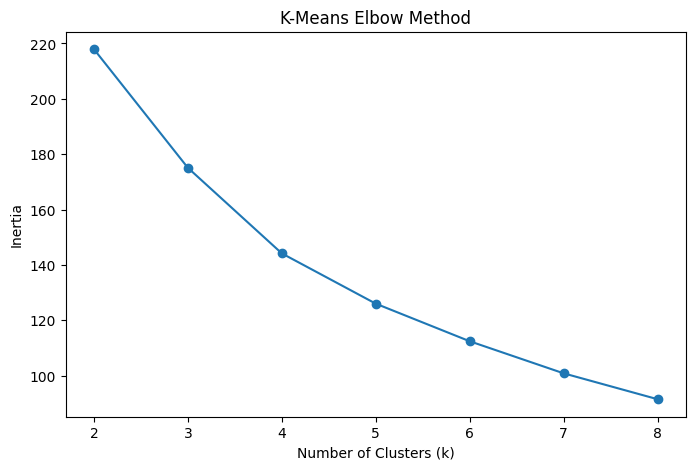

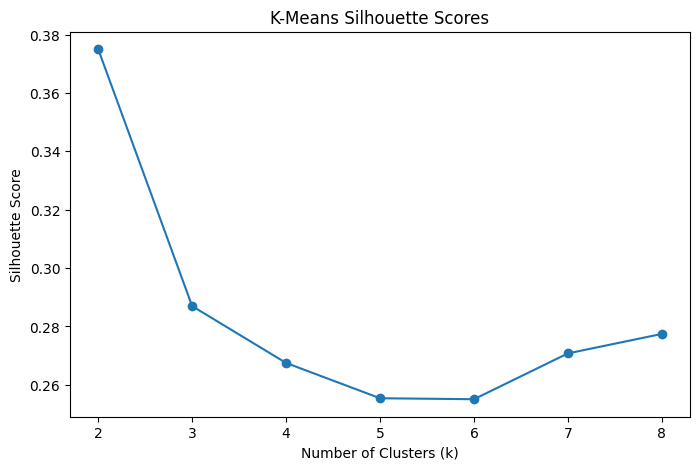

Best k by silhouette score: 2
Highest silhouette score: 0.375


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 9)
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,5))
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.xticks(list(ks))
plt.show()

plt.figure(figsize=(8,5))
plt.plot(list(ks), sil_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Scores")
plt.xticks(list(ks))
plt.show()

best_k = list(ks)[int(np.argmax(sil_scores))]
print("Best k by silhouette score:", best_k)
print("Highest silhouette score:", round(max(sil_scores), 4))

In [9]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
klabels = kmeans.fit_predict(X_scaled)
pca_df["KMeans_Cluster"] = klabels

print("K-Means cluster sizes:")
print(pd.Series(klabels).value_counts().sort_index())
print("Final K-Means silhouette:", round(silhouette_score(X_scaled, klabels), 4))

K-Means cluster sizes:
0    49
1    51
Name: count, dtype: int64
Final K-Means silhouette: 0.375


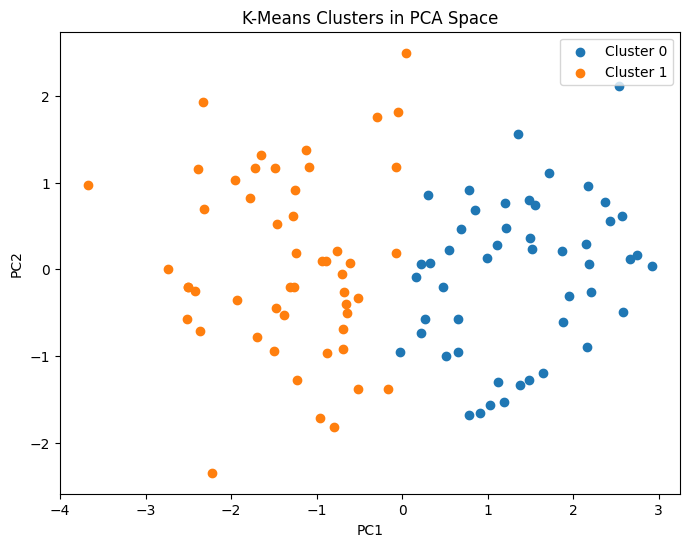

In [10]:
plt.figure(figsize=(8,6))
for c in sorted(pca_df["KMeans_Cluster"].unique()):
    s = pca_df[pca_df["KMeans_Cluster"] == c]
    plt.scatter(s["PC1"], s["PC2"], label=f"Cluster {c}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters in PCA Space")
plt.legend()
plt.show()

## 5. DBSCAN

DBSCAN is a density-based method that can identify noise and does not require a pre-specified number of clusters.

In [11]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=1.25, min_samples=5)
dlabels = db.fit_predict(X_scaled)
pca_df["DBSCAN_Cluster"] = dlabels

print("DBSCAN cluster counts:")
print(pd.Series(dlabels).value_counts().sort_index())

non_noise = dlabels != -1
if len(set(dlabels[non_noise])) >= 2:
    db_sil = silhouette_score(X_scaled[non_noise], dlabels[non_noise])
    print("DBSCAN silhouette excluding noise:", round(db_sil, 4))
else:
    db_sil = np.nan
    print("Not enough non-noise clusters for a silhouette score.")

DBSCAN cluster counts:
-1     8
 0    92
Name: count, dtype: int64
Not enough non-noise clusters for a silhouette score.


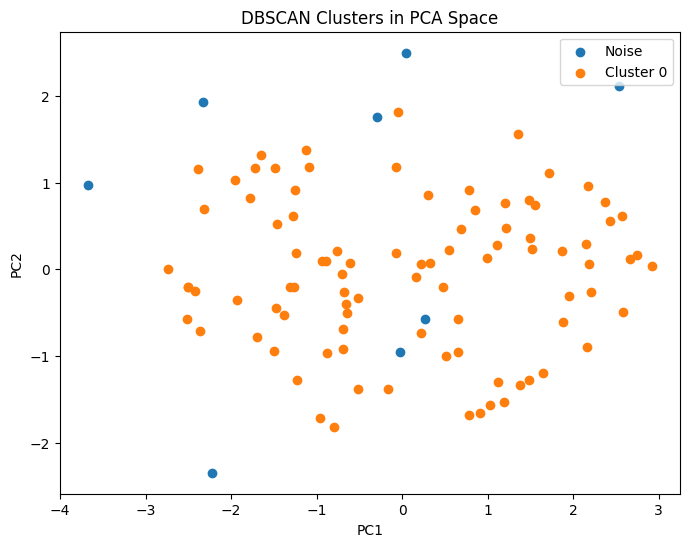

In [12]:
plt.figure(figsize=(8,6))
for c in sorted(pca_df["DBSCAN_Cluster"].unique()):
    s = pca_df[pca_df["DBSCAN_Cluster"] == c]
    label = "Noise" if c == -1 else f"Cluster {c}"
    plt.scatter(s["PC1"], s["PC2"], label=label)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters in PCA Space")
plt.legend()
plt.show()

## 6. Hierarchical Clustering

Agglomerative hierarchical clustering progressively merges similar observations. The number of clusters is set to the K-Means silhouette-selected k for comparison.

In [13]:
from sklearn.cluster import AgglomerativeClustering

hier = AgglomerativeClustering(n_clusters=best_k)
hlabels = hier.fit_predict(X_scaled)
pca_df["Hierarchical_Cluster"] = hlabels

h_sil = silhouette_score(X_scaled, hlabels)
print("Hierarchical cluster sizes:")
print(pd.Series(hlabels).value_counts().sort_index())
print("Hierarchical silhouette:", round(h_sil, 4))

Hierarchical cluster sizes:
0    51
1    49
Name: count, dtype: int64
Hierarchical silhouette: 0.3682


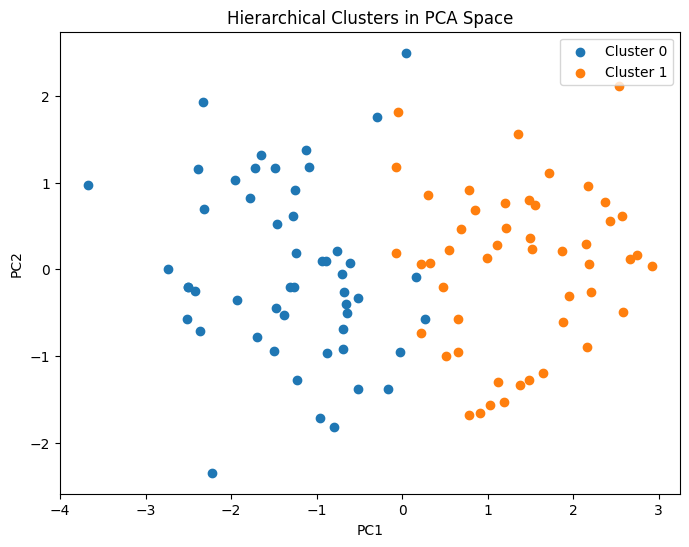

In [14]:
plt.figure(figsize=(8,6))
for c in sorted(pca_df["Hierarchical_Cluster"].unique()):
    s = pca_df[pca_df["Hierarchical_Cluster"] == c]
    plt.scatter(s["PC1"], s["PC2"], label=f"Cluster {c}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clusters in PCA Space")
plt.legend()
plt.show()

## 7. Final Findings

Silhouette scores are used as one comparison measure; visualizations should also be considered. Since the data are synthetic, the clustering results are methodological examples rather than claims about real students.

In [15]:
comparison = pd.DataFrame({
    "Method": ["K-Means", "Hierarchical"],
    "Silhouette Score": [
        silhouette_score(X_scaled, klabels),
        h_sil
    ]
})
if not np.isnan(db_sil):
    comparison.loc[len(comparison)] = ["DBSCAN (excluding noise)", db_sil]

display(comparison.round(4))
print("Observations:", len(df))
print("Components for >=90% variance:", n90)
print("Best K-Means k:", best_k)
print("Conclusion: PCA reduced the feature space for visualization, while K-Means, DBSCAN, and hierarchical clustering explored groups in the synthetic student data.")

,Method,Silhouette Score
0,K-Means,0.3750
1,Hierarchical,0.3682


Observations: 100
Components for >=90% variance: 3
Best K-Means k: 2
Conclusion: PCA reduced the feature space for visualization, while K-Means, DBSCAN, and hierarchical clustering explored groups in the synthetic student data.
